# Besafe Training using vecotizers

This is the script that was used to crreat the Besafe model with tensorflow tokenizer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras.models import Sequential
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.layers import TextVectorization,Embedding,LSTM,Dense,Dropout,Bidirectional
from tensorflow.keras.optimizers import Adam
import re

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataPath = ''
VOCAB_SIZE =10000
MAX_LEN=100

In [32]:
data= pd.read_csv(dataPath)

In [ ]:
data['Label'].value_counts()

In [69]:
def clean_text(text):
    text = str(text)
    # Remove URLs, mentions, special characters (keep letters and spaces)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s\u0600-\u06FF]', '', text)  # Keep English/Arabic letters
    text = text.lower()
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [75]:
data['cleaned_text'] =data['Text'].apply(clean_text)

In [ ]:
data['cleaned_text'].sample(10)

In [79]:
x =data['cleaned_text'].values
y =data['Label'].values.astype(int)

In [80]:
len(y)

13405

In [83]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [84]:
len(x_train),len(x_test)

(10724, 2681)

In [93]:
# Instantiation onf Tokenizer
tokenizer=Tokenizer(num_words=VOCAB_SIZE,oov_token='<OOV>')
tokenizer.fit_on_texts(x_train)

# Convert Training and Testing Df to sequences
train_sequence=tokenizer.texts_to_sequences(x_train)
test_sequence=tokenizer.texts_to_sequences(x_test)

# Padd Them to commonize everything
x_trainPadded=pad_sequences(train_sequence,maxlen=MAX_LEN,padding='post',truncating='post')
x_testPadded=pad_sequences(test_sequence,maxlen=MAX_LEN,padding='post',truncating='post')

In [94]:
y_trainNumerical=np.array(y_train)
y_testNumerical=np.array(y_test)

In [ ]:
print("Unique labels:", set(y_testNumerical))
print("Data type:", type(y_trainNumerical[0]))

In [96]:
with open('/content/drive/MyDrive/Besafetokenizer1.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [97]:
EMBEDDING_DIM =128
LSTM_UNITS =32
# Model parameters

model = models.Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(LSTM_UNITS, dropout=0.3, return_sequences=False)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)
model.build(input_shape=(None, MAX_LEN))


In [ ]:
model.summary()

In [91]:
callbacks=[
    tf.keras.callbacks.EarlyStopping(patience=5,restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(filepath='/content/drive/MyDrive/BEsafe_models/BesafeBesafeCleanedTokenizer2.h5',save_best_only=True)
]

In [ ]:

history = model.fit(
    x_trainPadded,
    y_trainNumerical,
    validation_split=0.3,  # Use part of training for validation
    epochs=60,
    shuffle=True,
    batch_size=32,
    callbacks=callbacks
)

In [99]:
reults = model.evaluate(x_testPadded, y_testNumerical)
print("Test Accuracy:", reults[1])
print("Test Precision:", reults[2])

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9868 - loss: 0.0507 - precision_4: 0.9900 - recall_4: 0.9859
Test Accuracy: 0.9847071766853333
Test Precision: 0.9870041012763977


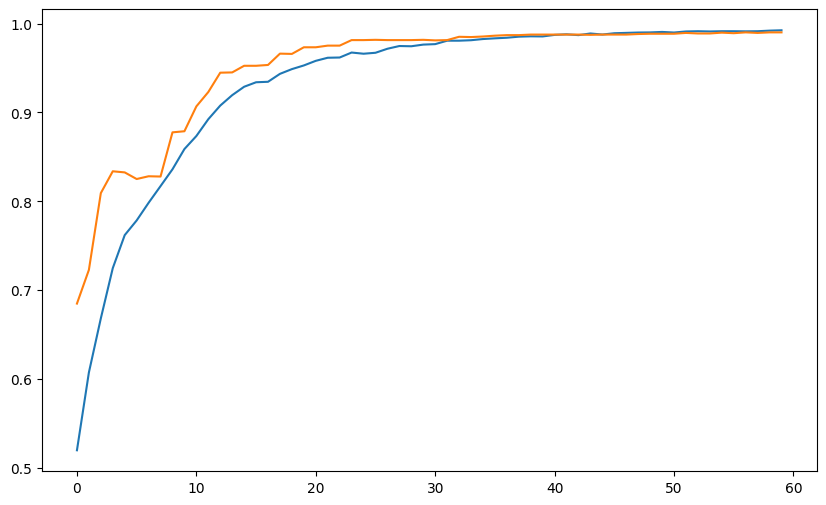

In [100]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.show()

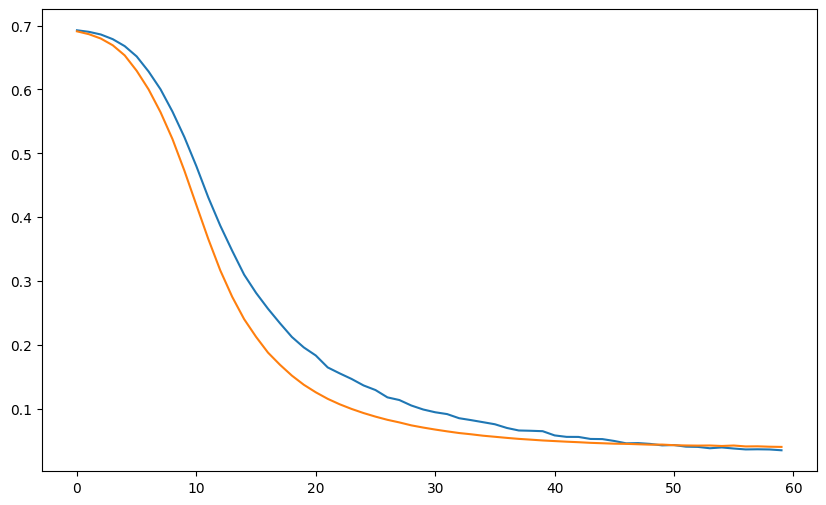

In [101]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.show()

#Testing of Unknown data now